# CROP YIELD PREDICTION

The main purpose of our work is to create a regressor model able to predict tomato yield in an equatorial environment (more specifically Cameroon), our goal is to reach a RMSPE of 10% for this first version, we'll improve later.

In [19]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
yield_df = pd.read_csv('./datasets/crop_yield_dataset.csv')
yield_df.head()

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,2014-01-01,Wheat,Peaty,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333
1,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
2,2014-01-01,Rice,Peaty,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333
3,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
4,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667


In [6]:
yield_df.shape

(36520, 12)

In [5]:
yield_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36520 entries, 0 to 36519
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          36520 non-null  object 
 1   Crop_Type     36520 non-null  object 
 2   Soil_Type     36520 non-null  object 
 3   Soil_pH       36520 non-null  float64
 4   Temperature   36520 non-null  float64
 5   Humidity      36520 non-null  float64
 6   Wind_Speed    36520 non-null  float64
 7   N             36520 non-null  float64
 8   P             36520 non-null  float64
 9   K             36520 non-null  float64
 10  Crop_Yield    36520 non-null  float64
 11  Soil_Quality  36520 non-null  float64
dtypes: float64(9), object(3)
memory usage: 3.3+ MB


This dataset seems to have any non-null value which is a very good thing for us.

In [7]:
yield_df.describe()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
count,36520.000000,36520.000000,36520.000000,36520.000000,36520.000000,36520.000000,36520.00000,36520.000000,36520.000000
mean,6.602731,23.813996,74.256624,10.020153,66.011035,53.014006,42.01825,26.878480,37.516632
std,0.816973,8.920519,6.767587,2.998310,10.886721,8.812884,8.53781,25.740936,17.703171
min,5.500000,-3.540176,45.851089,-3.388906,45.000000,36.000000,27.00000,0.000000,13.291667
25%,6.250000,17.168542,69.745252,7.985872,58.500000,45.000000,35.00000,0.000000,22.500000
50%,6.500000,22.902987,77.097013,10.000299,65.000000,54.000000,42.00000,23.366344,35.583333
75%,6.750000,30.254748,80.000000,12.038546,71.500000,60.000000,49.50000,46.415729,49.291667
max,8.000000,54.148911,80.000000,22.606078,91.000000,72.000000,60.00000,136.711982,74.333333


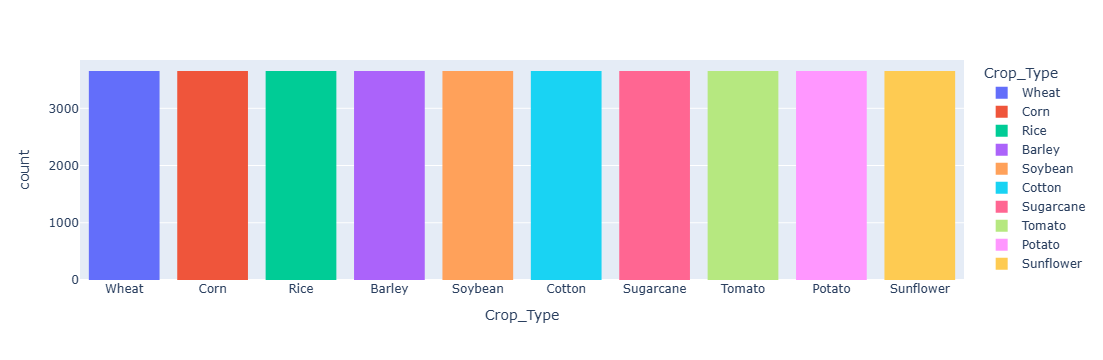

In [24]:
fig = px.histogram(yield_df,
           x='Crop_Type',
            color='Crop_Type')
fig.show()

We can observ that Crop_Type has a perfectly uniform distribution. But we'll only select Tomato crop_type.

## More context-centered specifications

Like we said before, we'll train our model on Cameroonian-like environment factors for tomato crop_type, we'll first of all: only select tomato crop_type, after that, we'll select data with environmental factors (temperature, humidity, wind_speed) which reflect the cameroonian-equatorial climate. 

In [25]:
tomato_df = yield_df[yield_df['Crop_Type']=='Tomato']
tomato_df.head(10)

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
7,2014-01-01,Tomato,Clay,6.25,18.323272,80.0,8.198084,60.0,45.0,40.0,22.221375,42.291667
17,2014-01-02,Tomato,Clay,6.25,19.877726,80.0,9.262757,60.0,45.0,40.0,31.009611,42.291667
27,2014-01-03,Tomato,Loamy,6.50,17.304778,80.0,13.821201,70.0,54.0,50.0,19.466158,58.000000
37,2014-01-04,Tomato,Sandy,6.75,15.384475,80.0,10.084298,50.0,36.0,30.0,1.864858,33.833333
47,2014-01-05,Tomato,Loamy,6.50,5.327149,80.0,6.426090,70.0,54.0,50.0,0.000000,58.000000
57,2014-01-06,Tomato,Clay,6.25,19.281994,80.0,12.130328,60.0,45.0,40.0,29.764974,42.291667
67,2014-01-07,Tomato,Saline,8.00,17.593472,80.0,8.876435,65.0,49.5,45.0,12.608629,13.291667
77,2014-01-08,Tomato,Clay,6.25,12.507967,80.0,14.629203,60.0,45.0,40.0,0.000000,42.291667
87,2014-01-09,Tomato,Saline,8.00,12.470600,80.0,7.513015,65.0,49.5,45.0,0.000000,13.291667
97,2014-01-10,Tomato,Sandy,6.75,17.480321,80.0,8.700090,50.0,36.0,30.0,13.945125,33.833333


In [26]:
tomato_df.describe()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
count,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,6.607407,23.908390,74.209307,9.992325,59.961665,44.965498,39.961665,22.794184,33.895206
std,0.810657,8.934391,6.835446,3.022899,7.069027,6.362124,7.069027,22.445509,15.567405
min,5.500000,0.424503,48.323659,-3.388906,50.000000,36.000000,30.000000,0.000000,13.291667
25%,6.250000,17.155095,69.636371,7.942058,55.000000,40.500000,35.000000,0.000000,21.750000
50%,6.500000,22.975930,77.024070,9.961859,60.000000,45.000000,40.000000,18.246919,33.833333
75%,6.750000,30.363629,80.000000,12.027262,65.000000,49.500000,45.000000,39.870070,42.291667
max,8.000000,51.676341,80.000000,22.606078,70.000000,54.000000,50.000000,96.454896,58.000000


By referring on World Bank, Britannica and FPS Foreign climate data, the Cameroonian climate is characterized by:
- A temperature: [16, 44]
- Humidity: [20,100]
- Wind_speed: [5-25]

In [ ]:
cmr_df = tomato_df[(tomato_df['temperature']<=44)
                    &(tomato_df['temperature']>=16)
                    &(tomato_df['humidity']>=20)
                    %(tomato_df['humidity'])]